In [1]:
!pip install prophet 
!pip install seaborn boto3
!pip install s3fs

In [2]:
import boto3
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
from pandas.api.types import CategoricalDtype
from datetime import datetime
from pandas.tseries.holiday import USFederalHolidayCalendar as calendar

In [3]:
warnings.filterwarnings("ignore")
plt.style.use('ggplot')
plt.style.use('fivethirtyeight')

def mean_absolute_percentage_error(y_true, y_pred): 
    """Calculates MAPE given y_true and y_pred"""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def create_features(df, label=None):
    """
    Creates time series features from datetime index.
    """
    df = df.copy()
    df['date'] = df.index
    df['hour'] = df['date'].dt.hour
    df['dayofweek'] = df['date'].dt.dayofweek
    df['weekday'] = df['date'].dt.day_name()
    df['weekday'] = df['weekday'].astype(cat_type)
    df['quarter'] = df['date'].dt.quarter
    df['month'] = df['date'].dt.month
    df['year'] = df['date'].dt.year
    df['dayofyear'] = df['date'].dt.dayofyear
    df['dayofmonth'] = df['date'].dt.day
    df['date_offset'] = (df.date.dt.month*100 + df.date.dt.day - 320) % 1300
    df['season'] = pd.cut(df['date_offset'], [0, 300, 602, 900, 1300], labels=['Spring', 'Summer', 'Fall', 'Winter'])
    X = df[['hour', 'dayofweek', 'quarter', 'month', 'year', 'dayofyear', 'dayofmonth', 'weekday', 'season']]
    if label:
        y = df[label]
        return X, y
    return X

In [4]:
# Nome do bucket e chave do objeto
s3_path = 's3://pmjelectricity/ref/hourly_pjme_consumption/run-1718652917790-part-block-0-r-00000-snappy.parquet'

# Carregar o arquivo Parquet do S3 no pandas
pjme = pd.read_parquet(s3_path)

# Verifique se a coluna 'datetime' está no formato datetime, caso contrário, converta
if not pd.api.types.is_datetime64_any_dtype(pjme['datetime']):
    pjme['datetime'] = pd.to_datetime(pjme['datetime'])

# Defina a coluna 'datetime' como índice
pjme.set_index('datetime', inplace=True)


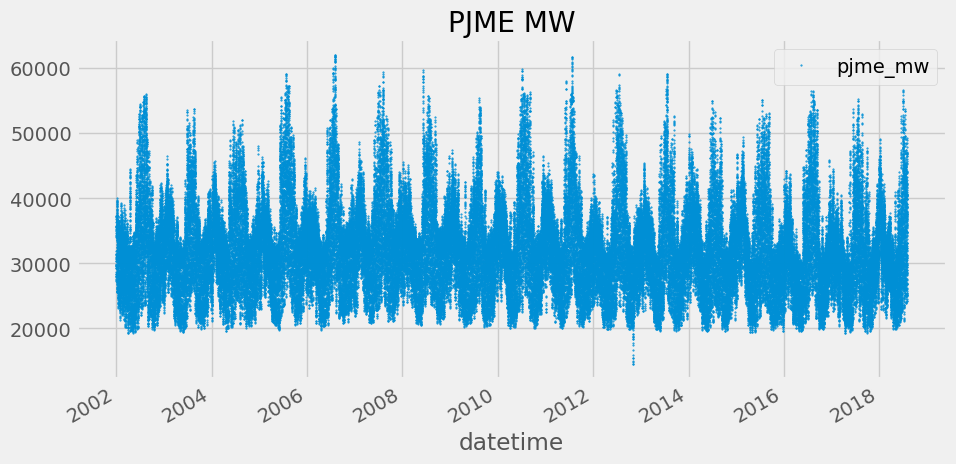

In [21]:
# Plotando os dados
color_pal = sns.color_palette()
pjme.plot(style='.', figsize=(10, 5), ms=1, color=color_pal[0], title='PJME MW')
plt.savefig("PJME.png")
plt.show()

cat_type = CategoricalDtype(categories=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], ordered=True)

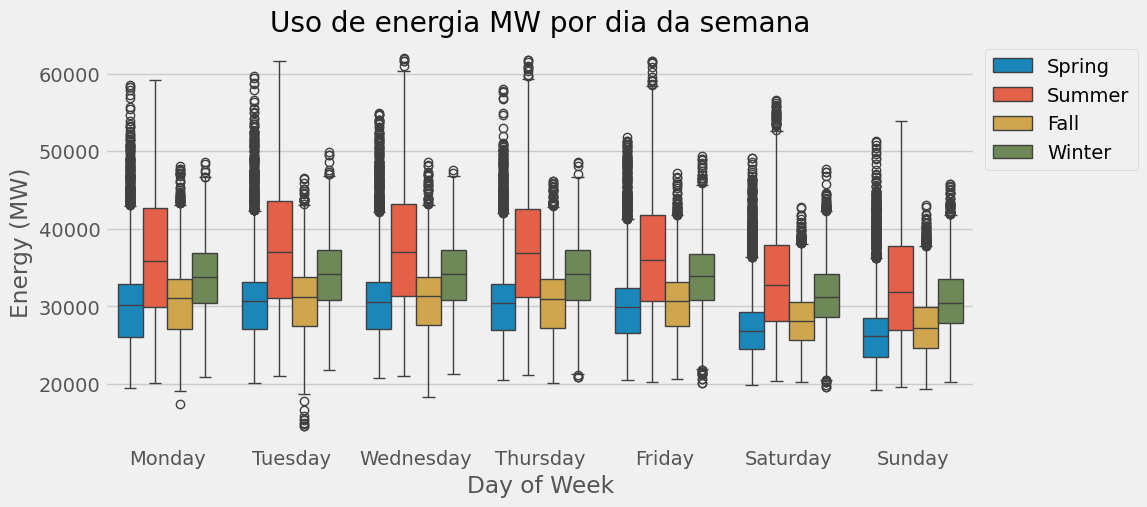

In [14]:
X, y = create_features(pjme, label='pjme_mw')
features_and_target = pd.concat([X, y], axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=features_and_target.dropna(), x='weekday', y='pjme_mw', hue='season', ax=ax, linewidth=1)
ax.set_title('Uso de energia MW por dia da semana')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Energy (MW)')
ax.legend(bbox_to_anchor=(1, 1))
plt.savefig("Uso de energia MW por dia da semana.png")
plt.show()

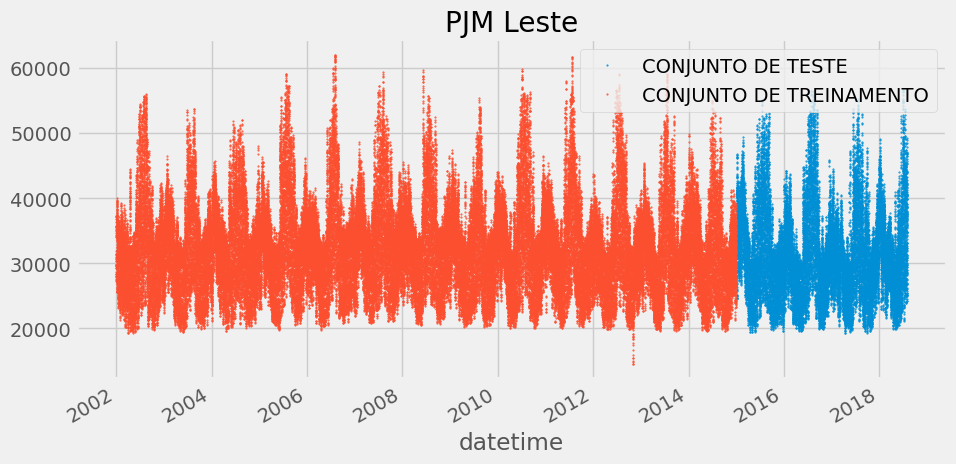

In [15]:
split_date = '1-Jan-2015'
pjme_train = pjme.loc[pjme.index <= split_date].copy()
pjme_test = pjme.loc[pjme.index > split_date].copy()

pjme_test.rename(columns={'pjme_mw': 'CONJUNTO DE TESTE'}).join(
    pjme_train.rename(columns={'pjme_mw': 'CONJUNTO DE TREINAMENTO'}), how='outer'
).plot(figsize=(10, 5), title='PJM Leste', style='.', ms=1)
plt.savefig("PJM Leste_Treinamento.png")
plt.show()

In [7]:
# Format data for prophet model using ds and y
pjme_train_prophet = pjme_train.reset_index().rename(columns={'datetime': 'ds', 'pjme_mw': 'y'})

model = Prophet()
model.fit(pjme_train_prophet)

# Predict on test set with model
pjme_test_prophet = pjme_test.reset_index().rename(columns={'datetime': 'ds', 'pjme_mw': 'y'})
pjme_test_fcst = model.predict(pjme_test_prophet)
pjme_test_fcst.head()


18:02:58 - cmdstanpy - INFO - Chain [1] start processing
18:05:21 - cmdstanpy - INFO - Chain [1] done processing


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2015-01-01 01:00:00,31207.918241,24056.001722,32689.655302,31207.918241,31207.918241,-2834.198162,-2834.198162,-2834.198162,-4430.433538,...,1281.423853,1281.423853,1281.423853,314.811522,314.811522,314.811522,0.0,0.0,0.0,28373.720079
1,2015-01-01 02:00:00,31207.880664,22656.278252,31192.551082,31207.880664,31207.880664,-4338.520484,-4338.520484,-4338.520484,-5927.305510,...,1272.660161,1272.660161,1272.660161,316.124864,316.124864,316.124864,0.0,0.0,0.0,26869.360180
2,2015-01-01 03:00:00,31207.843086,21722.391674,30611.505190,31207.843086,31207.843086,-5210.184323,-5210.184323,-5210.184323,-6790.355013,...,1262.691010,1262.691010,1262.691010,317.479681,317.479681,317.479681,0.0,0.0,0.0,25997.658763
3,2015-01-01 04:00:00,31207.805508,21469.529460,30323.752011,31207.805508,31207.805508,-5351.748460,-5351.748460,-5351.748460,-6922.264477,...,1251.640019,1251.640019,1251.640019,318.875997,318.875997,318.875997,0.0,0.0,0.0,25856.057048
4,2015-01-01 05:00:00,31207.767931,21715.821013,31565.966301,31207.767931,31207.767931,-4677.450293,-4677.450293,-4677.450293,-6237.407146,...,1239.643015,1239.643015,1239.643015,320.313838,320.313838,320.313838,0.0,0.0,0.0,26530.317638


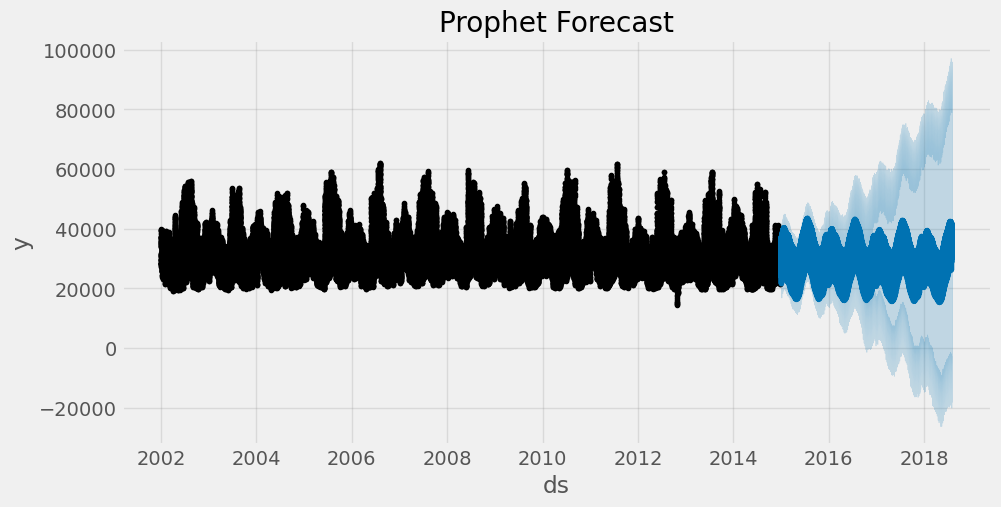

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
fig = model.plot(pjme_test_fcst, ax=ax)
ax.set_title('Prophet Forecast')
plt.savefig("Prophet Forecast.png")
plt.show()

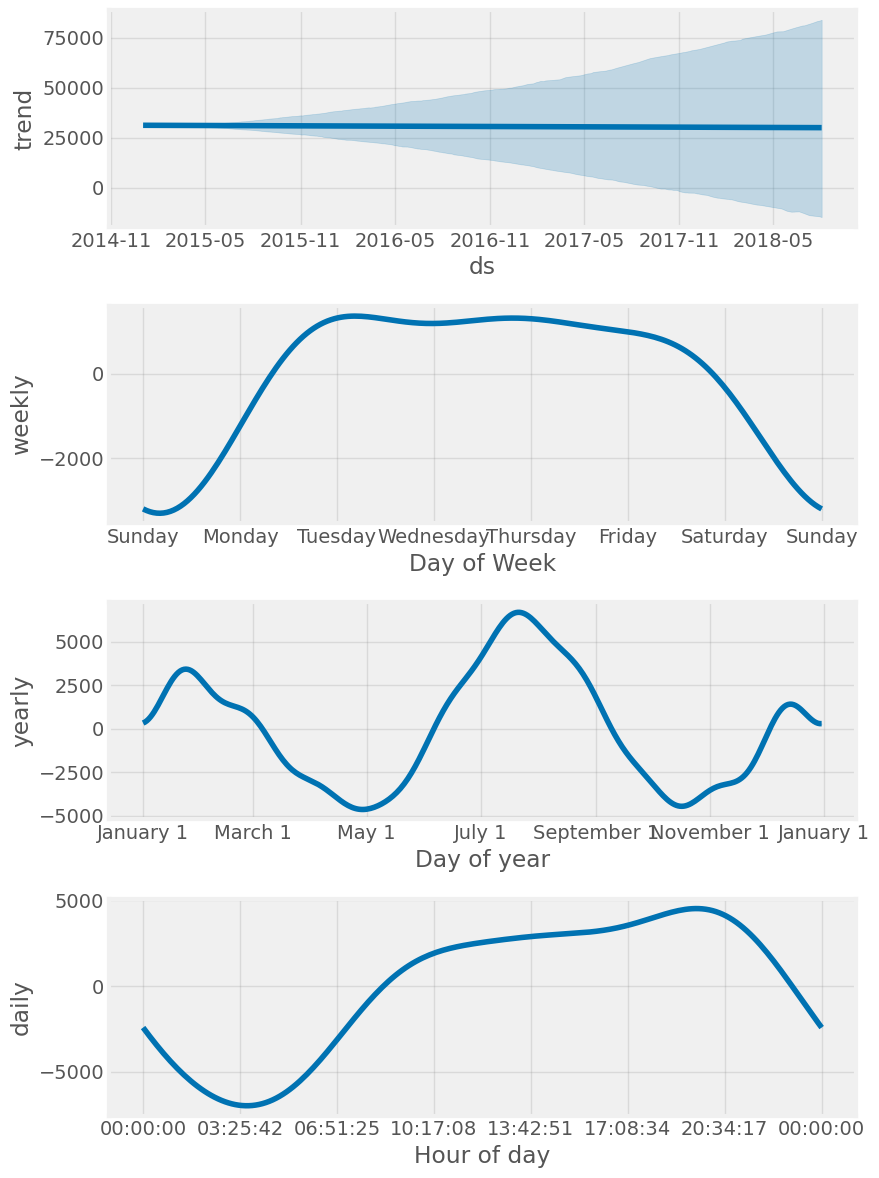

In [9]:
fig = model.plot_components(pjme_test_fcst)
plt.savefig("PJME_TEST_FCST.png")
plt.show()

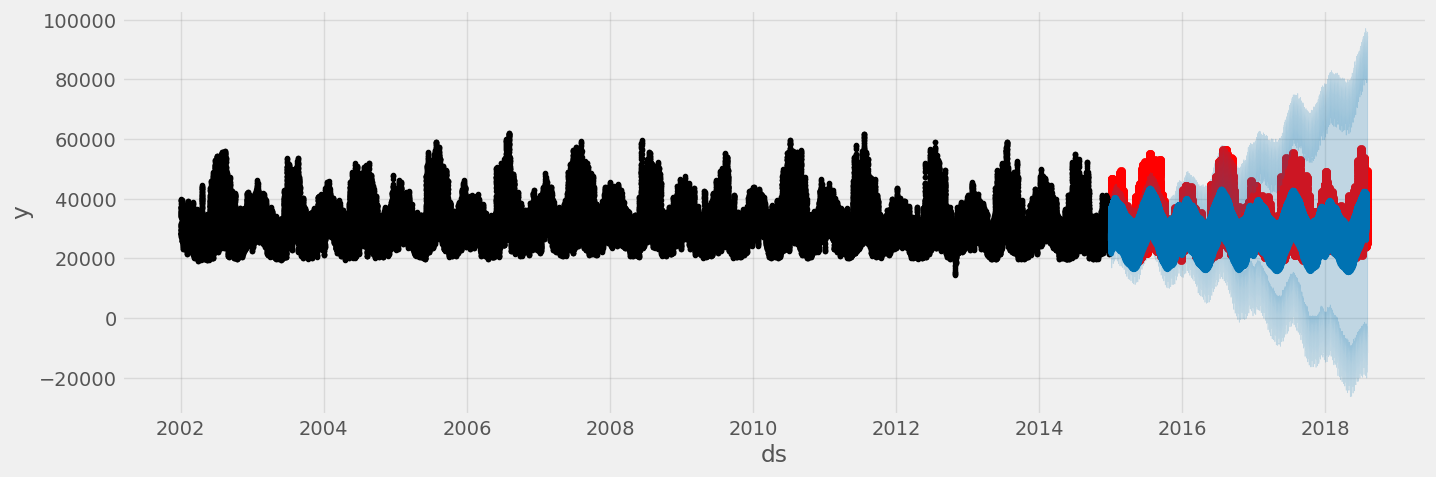

In [10]:

# Plot a previsão com os dados reais
f, ax = plt.subplots(figsize=(15, 5))
ax.scatter(pjme_test.index, pjme_test['pjme_mw'], color='r')
fig = model.plot(pjme_test_fcst, ax=ax)
plt.savefig("PJME_MW_FORECAST_WITH_REAL_DATA.png")


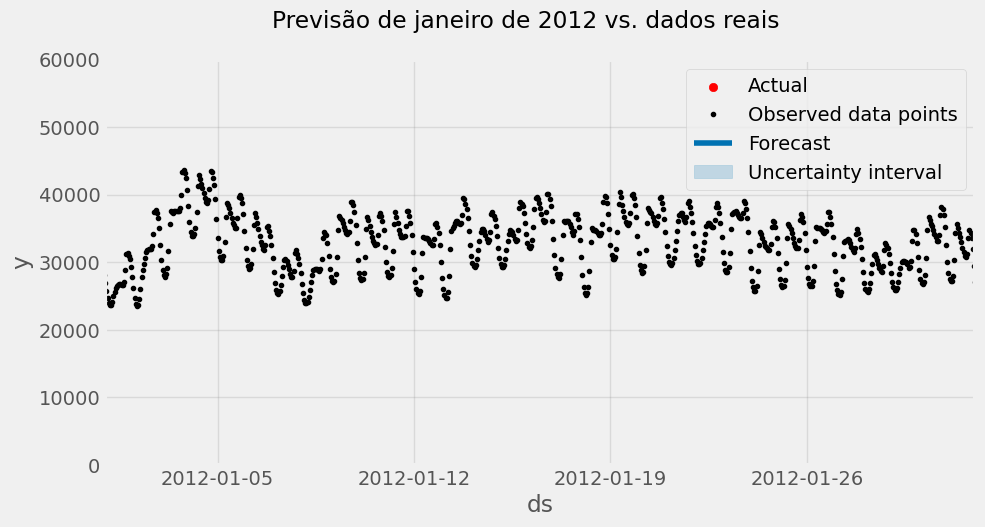

In [11]:
# Defina seus limites de data como objetos de data e hora
start_date = datetime.strptime('2012-01-01', '%Y-%m-%d')
end_date = datetime.strptime('2012-02-01', '%Y-%m-%d')

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(pjme_test.index, pjme_test['pjme_mw'], color='r', label='Actual')
fig = model.plot(pjme_test_fcst, ax=ax)
ax.set_xlim([start_date, end_date])
ax.set_ylim(0, 60000)
plt.suptitle('Previsão de janeiro de 2012 vs. dados reais')
ax.legend()
plt.savefig('Previsão de janeiro de 2012 vs. dados reais.png')
plt.show()

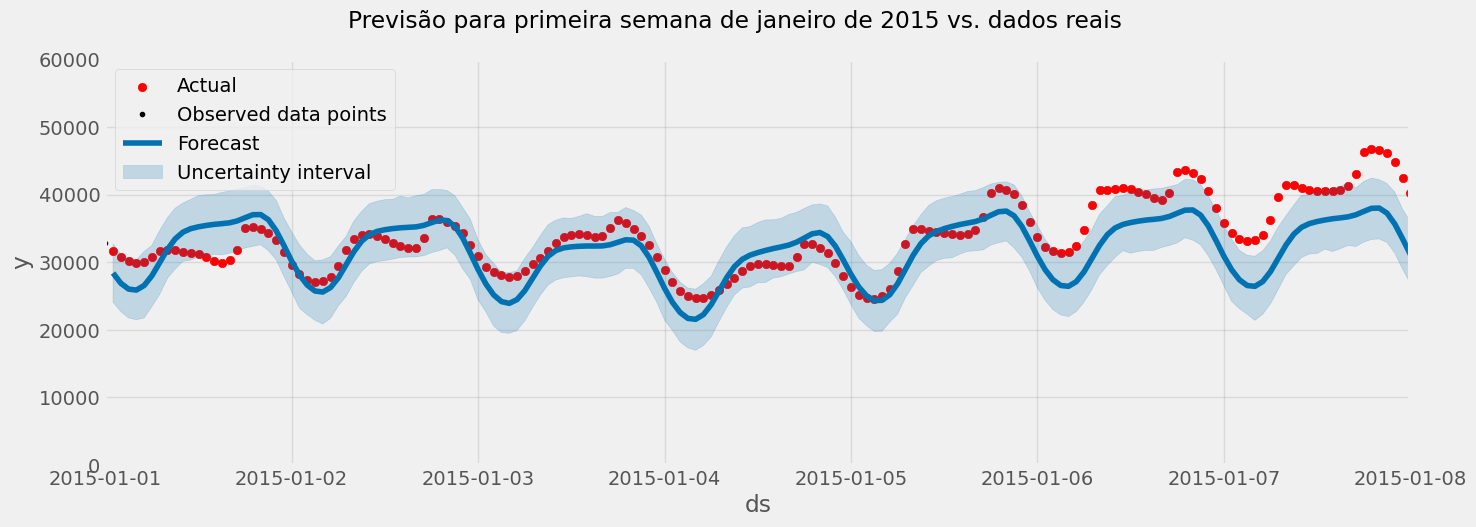

In [12]:
start_date = datetime.strptime('2015-01-01', '%Y-%m-%d')
end_date = datetime.strptime('2015-01-08', '%Y-%m-%d')

fig, ax = plt.subplots(figsize=(15, 5))
ax.scatter(pjme_test.index, pjme_test['pjme_mw'], color='r', label='Actual')
fig = model.plot(pjme_test_fcst, ax=ax)
ax.set_xlim([start_date, end_date])
plt.suptitle('Previsão para primeira semana de janeiro de 2015 vs. dados reais')
ax.set_ylim(0, 60000)
ax.legend()
plt.savefig('Previsão para primeira semana de janeiro de 2015 vs. dados reais.png')
plt.show()

In [13]:
y_true = pjme_test['pjme_mw']
y_pred = pjme_test_fcst['yhat'].values

print('Mean Absolute Percentage Error:', mean_absolute_percentage_error(y_true, y_pred))
print('Mean Absolute Error:', mean_absolute_error(y_true, y_pred))
print('Root Mean Squared Error:', mean_squared_error(y_true, y_pred) ** 0.5)


Mean Absolute Percentage Error: 16.509120045288032
Mean Absolute Error: 5182.6033081076885
Root Mean Squared Error: 6616.681209470304
